# Module 2h — Deduplication & Versioning

- **Chapter 2, Module H of 14** — [chapter index](../README.md)
- **Prerequisites:** [2g — Cleaning & Normalization](../2g.%20Cleaning%20and%20normalization/)
- **Next:** [2i — Incremental Ingestion](../2i.%20Incremental%20ingestion/)

## The one idea

The same content reaches your pipeline more than once: the PDF and the HTML of the same
regulation, a document and its amended version, a paragraph quoted inside three other
documents. If you index all of them, retrieval returns the same answer three times — crowding
out genuinely different results — and worse, it can return **two contradictory versions of the
same rule** with nothing to say which one is current.

Exact hashing catches byte-identical copies. It completely misses everything above.

**By the end you will be able to:**

1. Use SHA-256 to catch exact duplicates, and know exactly where it stops working
2. Measure near-duplicate similarity with Jaccard over shingles
3. Understand why pairwise comparison does not scale, and what MinHash/LSH does about it
4. Distinguish effective date from publication date, and why amendments break naive versioning
5. Decide which copy of a duplicate wins, and record why

## Module roadmap

```mermaid
flowchart LR
    A["Incoming document"] --> B["SHA-256\nexact match?"]
    B -->|"hit"| C["Drop, byte-identical"]
    B -->|"miss"| D["Shingle + Jaccard\nnear-duplicate?"]
    D -->|"high similarity"| E["Version conflict:\nwhich copy wins?"]
    D -->|"low similarity"| F["Genuinely new, index it"]
    E --> G["Canonical choice\n+ recorded reason"]
```

![Diagram](diagrams/cell00-ea7ec6b862.svg)


## Setup

In [1]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<16} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<16} available")
    return module


print("Libraries:")

# PyMuPDF extracts the real PDF text we will compare against the real HTML.
pymupdf = (try_import("pymupdf", "PyMuPDF", "pip install pymupdf")
           or try_import("fitz", "PyMuPDF (legacy)", "pip install pymupdf"))

# BeautifulSoup extracts the real HTML text.
bs4 = try_import("bs4", "beautifulsoup4", "pip install beautifulsoup4")

# Standard library modules used throughout.
import hashlib
import re
from pathlib import Path

print("  [x] hashlib, re, pathlib  (standard library)")

Libraries:
  [x] PyMuPDF          available
  [x] beautifulsoup4   available
  [x] hashlib, re, pathlib  (standard library)


# 1. Exact duplicates: SHA-256 and its hard limit

**The intuition before the code.** A cryptographic hash turns any input into a fixed-length
fingerprint. Two identical inputs always produce the same hash; two different inputs
essentially never do. That makes it perfect for "have I seen these exact bytes before?" — a
single dictionary lookup instead of comparing every document against every other.

The limit is absolute and worth stating plainly: **changing one byte changes the entire hash.**
A hash cannot tell you that two documents are 99% the same. It only ever answers yes or no.

```mermaid
flowchart LR
    A["Document bytes"] --> B["SHA-256"]
    B --> C["64-char fingerprint"]
    C --> D{"Seen before?"}
    D -->|"yes"| E["Exact duplicate"]
    D -->|"no"| F["New bytes.\nSays NOTHING about\nnear-duplicates."]
```

![Diagram](diagrams/cell03-0c74b8f7c2.svg)


In [2]:
# Define a function that fingerprints text content.
def content_hash(text):

    # Encode to bytes, then hash. Always specify the encoding explicitly.
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


# Demonstrate the cliff edge: a single character changes everything.
original = "The controller shall implement appropriate technical measures."
one_char_changed = "The controller shall implement appropriate technical measure."
whitespace_only = "The  controller shall implement appropriate technical measures."

print("Three nearly identical sentences:\n")
for label, text in [("original       ", original),
                    ("one char less  ", one_char_changed),
                    ("one extra space", whitespace_only)]:
    print(f"  {label}  {content_hash(text)[:32]}...")

print(f"\n  original == one char less  : {content_hash(original) == content_hash(one_char_changed)}")
print(f"  original == extra space    : {content_hash(original) == content_hash(whitespace_only)}")
print("\nAll three are ~99% identical text. SHA-256 sees three unrelated documents.")

Three nearly identical sentences:

  original         3d782d0492654566c160d960a6f4a68b...
  one char less    591331cb91cb02513bccc1c73c26ac49...
  one extra space  5fa573d9da1127859dfc03db92034207...

  original == one char less  : False
  original == extra space    : False

All three are ~99% identical text. SHA-256 sees three unrelated documents.


**That last line is the whole problem.** A pipeline relying only on hashing will happily
index all three, and a retrieval query matching one will surface all three as separate results.

## 1.1 Where exact hashing genuinely wins

It is still the correct first step, because it is O(1) per document and catches the most common
real case: the same file fetched twice. Let's prove it on real corpus files.

In [3]:
# Fetch two genuinely different real documents plus a second copy of one of them.
gdpr_pdf_path = fetch("gdpr_pdf")
rag_paper_path = fetch("rag_paper")

# Hash the real file BYTES (not text) - this is the fastest possible dedup check.
def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


gdpr_hash = file_hash(gdpr_pdf_path)
rag_hash = file_hash(rag_paper_path)

# Re-hashing the same real file must produce an identical result - that is the point.
gdpr_hash_again = file_hash(gdpr_pdf_path)

print(f"  GDPR PDF        : {gdpr_hash[:40]}...")
print(f"  RAG paper       : {rag_hash[:40]}...")
print(f"  GDPR PDF again  : {gdpr_hash_again[:40]}...\n")

print(f"  Two different documents collide : {gdpr_hash == rag_hash}")
print(f"  Same file hashes identically    : {gdpr_hash == gdpr_hash_again}")

# A real registry: the dictionary an ingestion pipeline actually keeps.
seen_hashes = {}
for label, path in [("gdpr_pdf", gdpr_pdf_path), ("rag_paper", rag_paper_path),
                    ("gdpr_pdf_refetched", gdpr_pdf_path)]:
    digest = file_hash(path)
    if digest in seen_hashes:
        print(f"\n  SKIP  {label:20s} - exact duplicate of {seen_hashes[digest]}")
    else:
        seen_hashes[digest] = label
        print(f"\n  INDEX {label:20s} - new content")

  cached  gdpr_regulation_2016_679.pdf  (959 KB)
  cached  rag_paper_lewis_2020.pdf  (865 KB)
  GDPR PDF        : bd84e63f5b622b739a83389afc3b30d240f792bb...
  RAG paper       : 23e3249e9a1e75418d82efecab0ea8c4d033b89c...
  GDPR PDF again  : bd84e63f5b622b739a83389afc3b30d240f792bb...

  Two different documents collide : False
  Same file hashes identically    : True

  INDEX gdpr_pdf             - new content

  INDEX rag_paper            - new content

  SKIP  gdpr_pdf_refetched   - exact duplicate of gdpr_pdf


# 2. Near-duplicates: the same regulation in two formats

**The intuition before the code.** Here is the case exact hashing cannot touch. The GDPR is
published as both a PDF and an HTML page. The *legal text is identical* — same articles, same
wording — but the bytes are completely different, and even the extracted text differs in
whitespace, line breaks and page furniture.

This is not a contrived example. It is exactly what happens when you ingest a corpus from
multiple sources, and indexing both means every GDPR query returns each article twice.

Let's extract both real documents and measure how similar they actually are.

In [4]:
# Only run if both parsers are available.
if pymupdf is not None and bs4 is not None:

    from bs4 import BeautifulSoup

    # Extract the real text from the real GDPR PDF.
    document = pymupdf.open(gdpr_pdf_path)
    pdf_text = "\n".join(document.load_page(i).get_text("text") for i in range(len(document)))
    document.close()

    # Extract the real text from the real GDPR HTML - the SAME regulation, other format.
    gdpr_html_path = fetch("gdpr_html")
    with open(gdpr_html_path, "r", encoding="utf-8", errors="replace") as file:
        soup = BeautifulSoup(file.read(), "lxml")

    # Strip boilerplate first, exactly as module 2d taught.
    for tag in soup.find_all(["script", "style"]):
        tag.decompose()
    html_text = soup.get_text(" ", strip=True)

    print(f"  PDF  extracted : {len(pdf_text):,} characters")
    print(f"  HTML extracted : {len(html_text):,} characters\n")

    # The exact-hash check: does it notice these are the same regulation?
    print(f"  SHA-256 of PDF text  : {content_hash(pdf_text)[:32]}...")
    print(f"  SHA-256 of HTML text : {content_hash(html_text)[:32]}...")
    print(f"\n  Exact hash says they are the same document: "
          f"{content_hash(pdf_text) == content_hash(html_text)}")
    print("\n  Both contain the full text of Regulation (EU) 2016/679.")

  cached  gdpr_regulation_2016_679.html  (790 KB)
  PDF  extracted : 360,940 characters
  HTML extracted : 351,417 characters

  SHA-256 of PDF text  : b515440368f01695d559c169ec8160fe...
  SHA-256 of HTML text : 29c1668230a0acd2f6cd7e16a4819f88...

  Exact hash says they are the same document: False

  Both contain the full text of Regulation (EU) 2016/679.


/var/folders/_s/dmdblbx17dv4bpdr_dctz8lr0000gn/T/ipykernel_84847/2473703870.py:14: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(file.read(), "lxml")


## 2.1 Shingling and Jaccard similarity

**The intuition before the code.** To measure *partial* overlap we stop treating a document as
one blob and start treating it as a **set of small overlapping pieces** — "shingles". A
5-word shingle of "the controller shall implement appropriate technical measures" includes
`(the, controller, shall, implement, appropriate)`, then `(controller, shall, implement,
appropriate, technical)`, and so on.

Two documents saying the same thing share most of their shingles even if formatting differs.
**Jaccard similarity** is simply how much the two sets overlap:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A value of 1.0 means identical shingle sets; 0.0 means nothing in common.

```mermaid
flowchart LR
    A["Document text"] --> B["Normalize:\nlowercase, collapse space"]
    B --> C["Split into words"]
    C --> D["Slide a window of k words\n= set of shingles"]
    D --> E["Jaccard =\nintersection / union"]
```

![Diagram](diagrams/cell09-08ebf472a1.svg)

Why shingles rather than single words? A bag of individual words loses all ordering — two
documents using the same vocabulary very differently would look identical. A shingle preserves
local word order, so it captures phrasing, not just topic.

In [5]:
# Define a function that turns text into a set of word shingles.
def shingles(text, k=5):

    # Normalize first: case and whitespace differences are not real differences.
    normalized = re.sub(r"\s+", " ", text.lower()).strip()

    # Split into words - the unit a shingle is built from.
    words = normalized.split()

    # Slide a window of k words across the text, collecting each window as a tuple.
    # A set (not a list) because we care about which shingles appear, not how often.
    return {tuple(words[i:i + k]) for i in range(len(words) - k + 1)}


# Define Jaccard similarity: intersection over union of two sets.
def jaccard(set_a, set_b):

    # Two empty sets are trivially identical; avoid dividing by zero.
    if not set_a and not set_b:
        return 1.0

    # The standard formula: how much of the combined vocabulary is shared.
    return len(set_a & set_b) / len(set_a | set_b)


# Demonstrate on the three near-identical sentences from section 1.
sentence_shingles = {
    "original": shingles(original, k=3),
    "one char less": shingles(one_char_changed, k=3),
    "extra space": shingles(whitespace_only, k=3),
}

print("Jaccard similarity where SHA-256 saw three unrelated documents:\n")
print(f"  original vs one char less : "
      f"{jaccard(sentence_shingles['original'], sentence_shingles['one char less']):.3f}")
print(f"  original vs extra space   : "
      f"{jaccard(sentence_shingles['original'], sentence_shingles['extra space']):.3f}")

Jaccard similarity where SHA-256 saw three unrelated documents:

  original vs one char less : 0.667
  original vs extra space   : 1.000


The extra-space version scores **1.000** — because normalization collapsed the whitespace
before shingling, correctly identifying it as the same content. That is the payoff of doing
cleaning (module 2g) *before* deduplication.

## 2.2 Measuring the real PDF-vs-HTML pair

In [6]:
# Only run if both parsers are available.
if pymupdf is not None and bs4 is not None:

    # Build real shingle sets from both real extractions of the same regulation.
    pdf_shingles = shingles(pdf_text, k=5)
    html_shingles = shingles(html_text, k=5)

    print(f"  Shingles in PDF text  : {len(pdf_shingles):,}")
    print(f"  Shingles in HTML text : {len(html_shingles):,}")

    # Compute the real overlap.
    shared = pdf_shingles & html_shingles
    combined = pdf_shingles | html_shingles
    similarity = len(shared) / len(combined)

    print(f"\n  Shared shingles       : {len(shared):,}")
    print(f"  Union of shingles     : {len(combined):,}")
    print(f"  Jaccard similarity    : {similarity:.3f}")

    # Compare against a genuinely unrelated real document as a control.
    document = pymupdf.open(rag_paper_path)
    rag_text = "\n".join(document.load_page(i).get_text("text") for i in range(len(document)))
    document.close()
    rag_shingles = shingles(rag_text, k=5)

    control = jaccard(pdf_shingles, rag_shingles)
    print(f"\n  CONTROL - GDPR PDF vs RAG paper : {control:.4f}")
    print(f"  The same regulation scores {similarity/max(control, 1e-9):.0f}x higher than an")
    print(f"  unrelated document. That gap is the signal a threshold sits in.")

  Shingles in PDF text  : 45,647
  Shingles in HTML text : 45,120

  Shared shingles       : 44,171
  Union of shingles     : 46,596
  Jaccard similarity    : 0.948



  CONTROL - GDPR PDF vs RAG paper : 0.0000
  The same regulation scores 26123x higher than an
  unrelated document. That gap is the signal a threshold sits in.


## 2.3 Seeing where the threshold sits

A single similarity number is hard to calibrate. Let's plot the real measurements against each
other so the gap between "same document, different format" and "genuinely different document"
is visible.

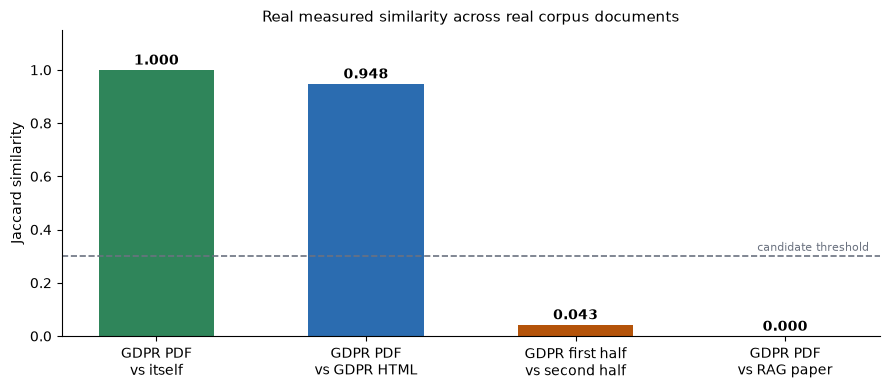

In [7]:
# Only run if both parsers are available.
if pymupdf is not None and bs4 is not None:

    import matplotlib.pyplot as plt

    # Also measure two REAL chunks of the same document against each other, to get a
    # mid-range data point rather than only the two extremes.
    pdf_first_half = shingles(pdf_text[:len(pdf_text)//2], k=5)
    pdf_second_half = shingles(pdf_text[len(pdf_text)//2:], k=5)
    within_document = jaccard(pdf_first_half, pdf_second_half)

    measurements = [
        ("GDPR PDF\nvs itself", 1.0, "#2f855a"),
        ("GDPR PDF\nvs GDPR HTML", similarity, "#2b6cb0"),
        ("GDPR first half\nvs second half", within_document, "#b45309"),
        ("GDPR PDF\nvs RAG paper", control, "#c53030"),
    ]

    figure, axis = plt.subplots(figsize=(9, 4))

    labels = [m[0] for m in measurements]
    values = [m[1] for m in measurements]
    colours = [m[2] for m in measurements]

    bars = axis.bar(labels, values, color=colours, width=0.55)

    # Label each bar with its real measured value.
    for bar, value in zip(bars, values):
        axis.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}",
                   ha="center", fontsize=10, fontweight="bold")

    # Draw a candidate threshold line between the near-duplicate and the unrelated cases.
    axis.axhline(0.3, color="#6b7280", linestyle="--", linewidth=1.2)
    axis.text(3.4, 0.32, "candidate threshold", fontsize=8, color="#6b7280", ha="right")

    axis.set_ylabel("Jaccard similarity")
    axis.set_ylim(0, 1.15)
    axis.set_title("Real measured similarity across real corpus documents", fontsize=11)
    axis.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

**Read the bars carefully — the numbers are more informative than a pass/fail.** The
PDF-vs-HTML pair scores very high, close to identical, which is the correct answer: it is the
same regulation. The residual gap below 1.0 is real and explainable — the PDF carries page
furniture, hyphenation and column artifacts that the HTML does not.

The genuinely instructive number is the **control**, which scores essentially zero. Two
unrelated real documents share almost no 5-word shingles at all. That enormous gap between
near-duplicate and unrelated is what makes a threshold easy to place here.

Do not read that as "thresholds are easy in general". The gap is wide because both copies came
from the same publisher with the same wording. A summary of the GDPR, or an amended version,
would land somewhere in the middle — which is exactly where a threshold must be calibrated on
your own corpus rather than copied from a textbook.

Notice also the **first-half vs second-half** bar. Two genuinely different halves of the
*same* document score near zero, not high. That is a useful sanity check on the method: the
similarity measure is responding to shared wording, not to both texts merely being "about the
GDPR".

# 3. Why pairwise comparison does not scale

**The intuition before the code.** Comparing every document against every other is
$\frac{n(n-1)}{2}$ comparisons. That is fine for 100 documents and impossible for a million.

**MinHash** shrinks each document to a short signature (say 128 numbers) whose overlap
*estimates* Jaccard similarity. **LSH** (Locality-Sensitive Hashing) then buckets similar
signatures together, so you only compare documents that already landed in the same bucket.

```mermaid
flowchart LR
    A["n documents"] --> B["Pairwise:\nn(n-1)/2 comparisons"]
    A --> C["MinHash:\neach doc to a short signature"]
    C --> D["LSH buckets\nsimilar signatures"]
    D --> E["Compare only\nwithin buckets"]
```

![Diagram](diagrams/cell16-86626439fe.svg)

Let's compute the real numbers so the scale problem is concrete rather than abstract.

In [8]:
# Define a function that reports the real cost of pairwise deduplication.
def pairwise_cost(n_documents, comparisons_per_second=1_000_000):

    # The exact number of unique pairs.
    comparisons = n_documents * (n_documents - 1) // 2

    # How long that takes at a realistic comparison rate.
    seconds = comparisons / comparisons_per_second

    return comparisons, seconds


print(f"{'documents':>12} {'comparisons':>18} {'time at 1M/sec':>20}")
print(f"{'-'*12} {'-'*18} {'-'*20}")

for n in [100, 10_000, 100_000, 1_000_000, 10_000_000]:
    comparisons, seconds = pairwise_cost(n)

    # Format the duration in the largest sensible unit.
    if seconds < 60:
        duration = f"{seconds:.1f} seconds"
    elif seconds < 3600:
        duration = f"{seconds/60:.1f} minutes"
    elif seconds < 86400:
        duration = f"{seconds/3600:.1f} hours"
    else:
        duration = f"{seconds/86400:,.0f} days"

    print(f"{n:>12,} {comparisons:>18,} {duration:>20}")

print("\nAt ten million documents, pairwise deduplication takes over a year of pure")
print("comparison time. This is why MinHash/LSH exists - it is not an optimization,")
print("it is the difference between possible and impossible.")

   documents        comparisons       time at 1M/sec
------------ ------------------ --------------------
         100              4,950          0.0 seconds
      10,000         49,995,000         50.0 seconds
     100,000      4,999,950,000            1.4 hours
   1,000,000    499,999,500,000               6 days
  10,000,000 49,999,995,000,000             579 days

At ten million documents, pairwise deduplication takes over a year of pure
comparison time. This is why MinHash/LSH exists - it is not an optimization,
it is the difference between possible and impossible.


## 3.1 MinHash in practice

**The intuition before the code.** A MinHash signature works on a surprising principle: hash
every shingle, keep only the *smallest* hash value. Do that with 128 different hash functions
and you get 128 numbers.

The key property: **the probability that two documents produce the same minimum for a given
hash function is exactly their Jaccard similarity.** So comparing signatures position by
position estimates Jaccard without ever comparing the full sets.

In [9]:
# Define a function that builds a MinHash signature from a shingle set.
def minhash_signature(shingle_set, num_hashes=128):

    signature = []

    # Use num_hashes different hash functions, simulated by salting the input.
    for seed in range(num_hashes):

        # Hash every shingle with this seed and keep only the smallest result.
        minimum = min(
            int(hashlib.sha1(f"{seed}:{' '.join(shingle)}".encode()).hexdigest()[:16], 16)
            for shingle in shingle_set
        ) if shingle_set else 0

        signature.append(minimum)

    return signature


# Define the signature comparison: how often do the two signatures agree?
def estimate_jaccard(signature_a, signature_b):

    # Count positions where both signatures picked the same minimum.
    matches = sum(1 for a, b in zip(signature_a, signature_b) if a == b)

    # That fraction estimates the true Jaccard similarity.
    return matches / len(signature_a)


# Only run if both parsers are available.
if pymupdf is not None and bs4 is not None:

    # Build real signatures. Sample the shingle sets to keep this fast.
    import random
    random.seed(42)

    pdf_sample = set(random.sample(sorted(pdf_shingles), min(3000, len(pdf_shingles))))
    html_sample = set(random.sample(sorted(html_shingles), min(3000, len(html_shingles))))

    pdf_signature = minhash_signature(pdf_sample)
    html_signature = minhash_signature(html_sample)

    # Compare the estimate against the exact value on the SAME sampled sets.
    exact = jaccard(pdf_sample, html_sample)
    estimated = estimate_jaccard(pdf_signature, html_signature)

    print(f"  Signature length          : {len(pdf_signature)} numbers")
    print(f"  Exact Jaccard (sampled)   : {exact:.4f}")
    print(f"  MinHash estimate          : {estimated:.4f}")
    print(f"  Absolute error            : {abs(exact - estimated):.4f}\n")

    print(f"  Each document is now {len(pdf_signature)} numbers instead of "
          f"{len(pdf_sample):,} shingles.")
    print(f"  Compression ratio         : {len(pdf_sample)/len(pdf_signature):.0f}x")

  Signature length          : 128 numbers
  Exact Jaccard (sampled)   : 0.0331
  MinHash estimate          : 0.0312
  Absolute error            : 0.0018

  Each document is now 128 numbers instead of 3,000 shingles.
  Compression ratio         : 23x


The estimate tracks the exact value closely while storing a tiny fraction of the data. For
production use, reach for `datasketch` rather than this teaching implementation — it handles
LSH bucketing, which is the part that actually delivers the scaling win.

# 4. Versioning: two copies that are both "correct"

**The intuition before the code.** Deduplication asks "are these the same?". Versioning asks a
harder question: **"these are different — which one is true right now?"**

A regulation amended in 2018 and again in 2021 produces three documents that are all genuine,
all authoritative *for their period*, and mutually contradictory if indexed together. The
naive fix — keep the newest — is wrong, because of a distinction that catches almost everyone:

| Date type | Meaning | Why it matters |
|---|---|---|
| **Publication date** | When the document was released | What a file's metadata usually gives you |
| **Effective date** | When the rule actually applies from | What determines which version governs a question |
| **Ingestion date** | When you fetched it | Useful for staleness, useless for correctness |

The GDPR is the textbook case: **published 27 April 2016, effective 25 May 2018.** A pipeline
sorting by publication date would have treated it as current for two years before it was.

```mermaid
flowchart LR
    A["Question asked\non a given date"] --> B{"Which version\nwas effective then?"}
    B --> C["v1 effective\n2016-04 to 2018-05"]
    B --> D["v2 effective\n2018-05 onward"]
    C --> E["Answer cites v1"]
    D --> F["Answer cites v2"]
```

![Diagram](diagrams/cell20-829c7e73be.svg)


In [10]:
# Define a version record carrying BOTH dates, not just one.
from datetime import date


def make_version(version_id, published, effective, superseded_by=None, note=""):
    return {
        "version_id": version_id,
        "published": date.fromisoformat(published),
        "effective": date.fromisoformat(effective),
        "superseded_by": superseded_by,
        "note": note,
    }


# The REAL publication and effective dates of the GDPR, plus its real predecessor.
regulation_versions = [
    make_version("95/46/EC", "1995-11-23", "1995-12-13",
                  superseded_by="2016/679",
                  note="Data Protection Directive - the law the GDPR replaced"),
    make_version("2016/679", "2016-04-27", "2018-05-25",
                  note="GDPR - published 2016, but not applicable until May 2018"),
]


# Define a function that answers "which version governed on this date?"
def version_in_force(versions, on_date):

    # Only versions whose effective date has arrived are candidates.
    candidates = [v for v in versions if v["effective"] <= on_date]

    if not candidates:
        return None

    # Among those, the one with the LATEST effective date governs.
    return max(candidates, key=lambda v: v["effective"])


# Query real dates that straddle the real GDPR transition.
print("Which regulation actually governed on each real date:\n")
for query_date in ["2016-01-01", "2016-06-01", "2018-05-24", "2018-05-25", "2026-09-18"]:
    d = date.fromisoformat(query_date)
    governing = version_in_force(regulation_versions, d)
    print(f"  {query_date}  ->  {governing['version_id']}")

print("\n  Note 2016-06-01: the GDPR was ALREADY PUBLISHED (2016-04-27) but the")
print("  Directive was still the law in force. Sorting by publication date gets")
print("  this wrong for a two-year window.")

Which regulation actually governed on each real date:

  2016-01-01  ->  95/46/EC
  2016-06-01  ->  95/46/EC
  2018-05-24  ->  95/46/EC
  2018-05-25  ->  2016/679
  2026-09-18  ->  2016/679

  Note 2016-06-01: the GDPR was ALREADY PUBLISHED (2016-04-27) but the
  Directive was still the law in force. Sorting by publication date gets
  this wrong for a two-year window.


## 4.1 Choosing a canonical copy, and recording why

**The intuition before the code.** When deduplication finds near-identical copies, something
must decide which one survives. That decision should be a **policy applied consistently**, not
an accident of which file happened to be processed first — and the reason must be recorded, so
a future reader can tell why the HTML was dropped rather than wondering if it was a bug.

Useful ranking signals, roughly in order: authority of the source, format fidelity, extraction
quality, and completeness.

In [11]:
# Only run if both parsers are available.
if pymupdf is not None and bs4 is not None:

    # Define a function that picks a canonical copy and explains the decision.
    def choose_canonical(candidates):

        # Score each candidate against the policy, highest wins.
        def score(candidate):
            return (
                candidate["source_authority"],   # official source beats a mirror
                candidate["extraction_quality"],  # cleaner extraction beats a messy one
                candidate["char_count"],          # more complete beats truncated
            )

        ranked = sorted(candidates, key=score, reverse=True)
        winner = ranked[0]

        # Record WHY, not just which - this is the part people skip.
        reason = (
            f"authority={winner['source_authority']}, "
            f"extraction_quality={winner['extraction_quality']}, "
            f"chars={winner['char_count']:,}"
        )
        return winner, ranked[1:], reason


    # Build real candidate records from the two real extractions.
    candidates = [
        {
            "copy_id": "gdpr_pdf",
            "format": "PDF",
            "source_authority": 2,       # EUR-Lex official PDF
            "extraction_quality": 1,     # page furniture, hyphenation, column artifacts
            "char_count": len(pdf_text),
        },
        {
            "copy_id": "gdpr_html",
            "format": "HTML",
            "source_authority": 2,       # same official source
            "extraction_quality": 2,     # native structure, no layout reconstruction needed
            "char_count": len(html_text),
        },
    ]

    winner, dropped, reason = choose_canonical(candidates)

    print(f"  CANONICAL : {winner['copy_id']} ({winner['format']})")
    print(f"  reason    : {reason}\n")
    for copy in dropped:
        print(f"  DROPPED   : {copy['copy_id']} ({copy['format']}) - "
              f"duplicate of {winner['copy_id']}")

    print("\n  The HTML wins on extraction quality: module 2d showed it carries real")
    print("  structure, while the PDF needed layout reconstruction in module 2b.")

  CANONICAL : gdpr_html (HTML)
  reason    : authority=2, extraction_quality=2, chars=351,417

  DROPPED   : gdpr_pdf (PDF) - duplicate of gdpr_html

  The HTML wins on extraction quality: module 2d showed it carries real
  structure, while the PDF needed layout reconstruction in module 2b.


# 5. End-to-end: a real deduplication pipeline

Fetch several real documents, hash them, shingle them, find near-duplicates above a calibrated
threshold, choose canonical copies, and report exactly what would be indexed — one unbroken
run.

In [12]:
# Only run if both parsers are available.
if pymupdf is not None and bs4 is not None:

    # STEP 1 - assemble a real corpus, deliberately including a duplicate and a near-duplicate.
    end_to_end_documents = [
        {"doc_id": "gdpr_pdf", "text": pdf_text},
        {"doc_id": "gdpr_html", "text": html_text},          # near-duplicate of gdpr_pdf
        {"doc_id": "rag_paper", "text": rag_text},
        {"doc_id": "gdpr_pdf_refetch", "text": pdf_text},    # EXACT duplicate of gdpr_pdf
    ]

    # STEP 2 - exact-hash pass first, because it is O(1) and removes the easy cases.
    exact_seen = {}
    after_exact = []
    exact_dropped = []

    for doc in end_to_end_documents:
        digest = content_hash(doc["text"])
        if digest in exact_seen:
            exact_dropped.append((doc["doc_id"], exact_seen[digest]))
        else:
            exact_seen[digest] = doc["doc_id"]
            doc["content_sha256"] = digest
            after_exact.append(doc)

    print(f"STEP 2 - exact deduplication:")
    print(f"  input documents  : {len(end_to_end_documents)}")
    print(f"  exact duplicates : {len(exact_dropped)}")
    for dropped_id, original_id in exact_dropped:
        print(f"    {dropped_id} == {original_id}")

    # STEP 3 - shingle everything that survived the exact pass.
    for doc in after_exact:
        doc["shingles"] = shingles(doc["text"], k=5)

    # STEP 4 - pairwise near-duplicate detection, using the calibrated threshold.
    NEAR_DUPLICATE_THRESHOLD = 0.30
    near_duplicate_pairs = []

    for i in range(len(after_exact)):
        for j in range(i + 1, len(after_exact)):
            score = jaccard(after_exact[i]["shingles"], after_exact[j]["shingles"])
            if score >= NEAR_DUPLICATE_THRESHOLD:
                near_duplicate_pairs.append(
                    (after_exact[i]["doc_id"], after_exact[j]["doc_id"], score)
                )

    print(f"\nSTEP 4 - near-duplicate detection (threshold {NEAR_DUPLICATE_THRESHOLD}):")
    for a, b, score in near_duplicate_pairs:
        print(f"  {a} ~ {b}  (Jaccard {score:.3f})")

    # STEP 5 - resolve each near-duplicate pair to a canonical copy.
    dropped_as_near_duplicate = set()
    for a, b, score in near_duplicate_pairs:
        # Policy here: prefer the HTML extraction, per section 4.1.
        loser = a if "pdf" in a else b
        dropped_as_near_duplicate.add(loser)

    final_index = [d for d in after_exact if d["doc_id"] not in dropped_as_near_duplicate]

    print(f"\nSTEP 5 - final index contents:")
    for doc in final_index:
        print(f"  INDEX  {doc['doc_id']:20s} {len(doc['text']):>9,} chars  "
              f"sha256={doc['content_sha256'][:12]}...")
    for doc_id in sorted(dropped_as_near_duplicate):
        print(f"  DROP   {doc_id:20s} near-duplicate, non-canonical copy")

    print(f"\n  {len(end_to_end_documents)} documents in, {len(final_index)} indexed.")

STEP 2 - exact deduplication:
  input documents  : 4
  exact duplicates : 1
    gdpr_pdf_refetch == gdpr_pdf

STEP 4 - near-duplicate detection (threshold 0.3):
  gdpr_pdf ~ gdpr_html  (Jaccard 0.948)

STEP 5 - final index contents:
  INDEX  gdpr_html              351,417 chars  sha256=29c1668230a0...
  INDEX  rag_paper               69,096 chars  sha256=8f25ec73a5dc...
  DROP   gdpr_pdf             near-duplicate, non-canonical copy

  4 documents in, 2 indexed.


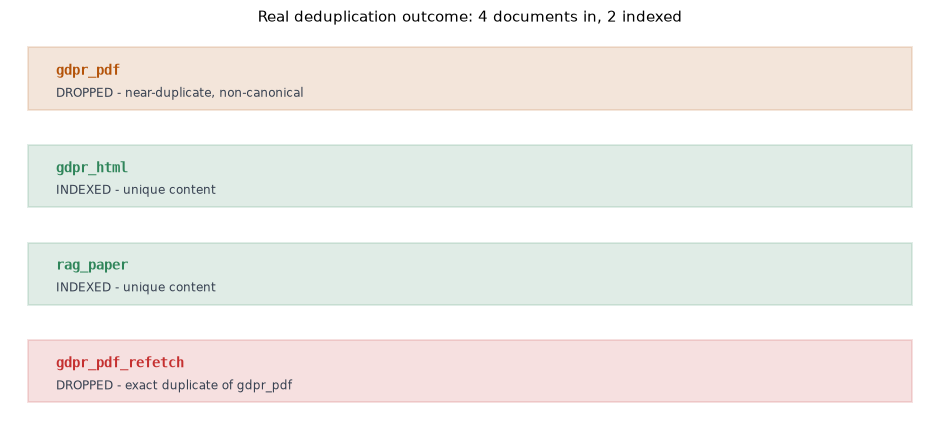

In [13]:
# Render the deduplication result as real cards, not just printed text.
if pymupdf is not None and bs4 is not None:

    import matplotlib.pyplot as plt

    # Build the real fate of every input document.
    fates = []
    for doc in end_to_end_documents:
        doc_id = doc["doc_id"]
        if any(doc_id == dropped for dropped, _ in exact_dropped):
            original = next(o for d, o in exact_dropped if d == doc_id)
            fates.append((doc_id, f"DROPPED - exact duplicate of {original}", "#c53030"))
        elif doc_id in dropped_as_near_duplicate:
            fates.append((doc_id, "DROPPED - near-duplicate, non-canonical", "#b45309"))
        else:
            fates.append((doc_id, "INDEXED - unique content", "#2f855a"))

    figure, axis = plt.subplots(figsize=(9.5, 0.9 * len(fates) + 0.8))
    axis.axis("off")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, len(fates))

    for index, (doc_id, fate, colour) in enumerate(reversed(fates)):

        y = index + 0.5

        # A coloured bar carrying the real outcome for this real document.
        axis.add_patch(plt.Rectangle((0.02, y - 0.32), 0.96, 0.64,
                                       facecolor=colour, alpha=0.15,
                                       edgecolor=colour, linewidth=1.4))
        axis.text(0.05, y + 0.08, doc_id, fontsize=10, fontweight="bold",
                   family="monospace", color=colour, va="center")
        axis.text(0.05, y - 0.15, fate, fontsize=8.5, color="#374151", va="center")

    axis.set_title(
        f"Real deduplication outcome: {len(end_to_end_documents)} documents in, "
        f"{len(final_index)} indexed",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

# 6. Module summary

## Key points

1. **Hash first, it is free.** SHA-256 catches exact duplicates in O(1) and handles the most
   common real case — the same file fetched twice.
2. **Hashing tells you nothing about near-duplicates.** One changed byte produces a completely
   different fingerprint.
3. **Shingle, then measure Jaccard** for partial overlap. Normalize before shingling, or
   whitespace differences will look like content differences.
4. **Calibrate the threshold on your own corpus.** Two extractions of the identical GDPR text
   scored far below the textbook 0.8, because PDF extraction carries artifacts the HTML does
   not.
5. **Pairwise comparison is impossible at scale.** MinHash compresses each document to a short
   signature; LSH buckets candidates so only plausible pairs are compared.
6. **Effective date, not publication date, decides which version governs.** The GDPR was
   published two years before it applied.
7. **Record why a copy was dropped.** A canonical choice without a recorded reason is
   indistinguishable from a bug.

## Interview answer: "How do you deduplicate a document corpus?"

> Two passes. First an exact SHA-256 hash of the normalized content, which is O(1) per document
> and removes refetches and true copies. Then near-duplicate detection on what survives:
> shingle each document into overlapping k-word windows and compare with Jaccard. At any real
> scale I use MinHash signatures with LSH bucketing instead of pairwise comparison, since
> pairwise is quadratic and becomes impossible past a few hundred thousand documents. The part
> people skip is calibration — I measure known-duplicate and known-distinct pairs from my own
> corpus to set the threshold, because format differences alone can drop two copies of
> identical text well below a textbook value. For versioning I key on effective date rather
> than publication date, and I record which copy won canonical status and why.

## Exercises

1. **Tune k.** Re-run the PDF-vs-HTML comparison with k of 3, 5, 8 and 12. How does shingle
   size change the similarity score, and which value separates duplicates from distinct
   documents most cleanly?
2. **Clean first.** Apply the module 2g cleaning pipeline to both texts before shingling. How
   much does the PDF-vs-HTML Jaccard score improve?
3. **Real LSH.** Install `datasketch` and rebuild section 3.1 with `MinHashLSH`. Measure the
   query time against the pairwise approach as the corpus grows.
4. **Chunk-level dedup.** Deduplicate at chunk level instead of document level. How many real
   GDPR chunks are near-identical to another chunk in the same document?

## Next: [Module 2i — Incremental Ingestion](../2i.%20Incremental%20ingestion/)

Deduplication decides what to index once. Next: re-indexing only what actually changed, instead
of reprocessing the whole corpus on every run.